# Young’s Double Slit Experiment (YDSE) – 3D Simulation

This notebook simulates the interference pattern in Young’s Double Slit Experiment using wave superposition.

## Physics Behind the Simulation

The intensity at any point is calculated using:

I ∝ |E₁ + E₂|²

where E₁ and E₂ are the electric field contributions from the two slits.

The simulation visualizes:
- 3D interference patterns
- Spatial variation of intensity
- Effect of phase difference on fringe formation

## Goal

To build an intuitive and visual understanding of how interference emerges from the superposition of waves.

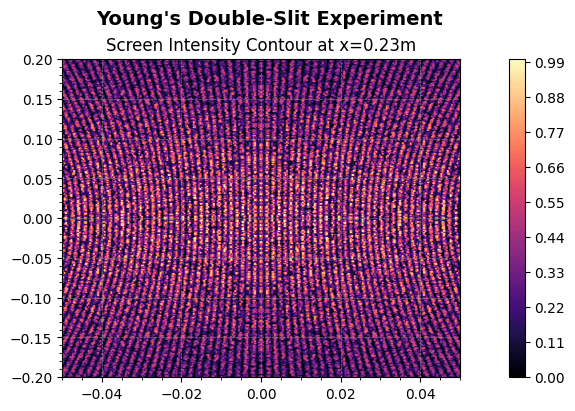

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import cm
from matplotlib import colors
from mpl_toolkits.mplot3d import axes3d



#Data input from user:




S=float(input("whats the screen pos? :"))
t=float(input("t at which to present the snapshot? :"))

#Initialize:

x=np.linspace(0,S,300)
y=np.linspace(-0.05,0.05, 300)
z=np.linspace(-0.2, 0.2, 300)


X,Y=np.meshgrid(x,y)

Γ,ζ=np.meshgrid(y,z)

#Constants :

λ=6.5*10**-7
c=3e8 # 3e8 m/s
A=1


k=2*np.pi/λ  
ω=c*k #

d=1e-4






s1=(0,d/2,0)
s2=(0,-d/2,0)

# Defining the light waves:

def o1(x,y,z,t):

    r1 = np.sqrt((x-s1[0])**2 + (y-s1[1])**2 +(z-s1[2])**2 )
    a=(A/r1)*np.sin(ω*t-k*r1)
    return a

def o2(x,y,z,t):

    r2 = np.sqrt((x-s2[0])**2 + (y-s2[1])**2 + (z-s2[2])**2)
    a= (A/r2)*np.sin(ω*t-k*r2)
    return a

def get_wave():
    wave = np.where(X<=S,((o1(X,Y,1,t) + o2(X,Y,1,t))**2),0)
    return wave

#Intensity (instantanous) calculation:

def get_int_screen(S,t):
    I=(o1(S,Γ,ζ,t)+o2(S,Γ,ζ,t))**2
    
    I0=(o1(S,y,0,t)+o2(S,y,0,t))**2
    
    return I , I0


#Plotting:
def plot(S,t):
    

    fig, ax2 = plt.subplots(figsize=(6, 4), constrained_layout=True)

    fig.suptitle("Interference Experiment",
             fontsize=14,
             fontweight="bold")
    

    ax2.set_title(f"Screen Intensity Contour at x={S}m")
    ax2.set_box_aspect(0.8)

    ax2.set_xlim(min(y), max(y))
    ax2.set_ylim(min(z), max(z))

    cont2 = ax2.contourf(
    Γ,
    ζ,
    get_int_screen(S, t)[0] / np.max(get_int_screen(S, t)[0]),
    levels=100,
    cmap="magma")

    ax2.grid(True, color="gray", linestyle="--", linewidth=0.5)
    ax2.minorticks_on()

    fig.colorbar(
    cont2,
    ax=ax2,
    orientation="vertical",
    pad=0.1,
    fraction=0.08)

    plt.show()
 

plot(S,t)


# Time avg intensity

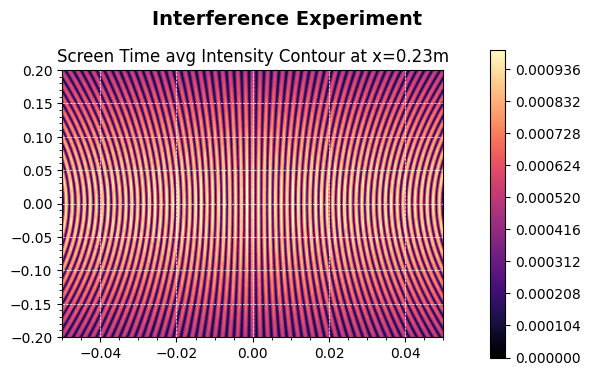

In [40]:
t1=np.linspace(0,1,1000)

I=np.zeros_like(get_int_screen(S,0)[0])
I0=np.zeros_like(get_int_screen(S,0)[1])

for n in t1:

 I+=get_int_screen(S,n)[0]
 I0+=get_int_screen(S,n)[1]
 
I=I/np.max(I)
I0=I0/np.max(I0)

fig, ax1 = plt.subplots(figsize=(6,4))

fig.suptitle("Interference Experiment",
             fontsize=14,
             fontweight="bold")

ax1.set_title(f"Screen Time avg Intensity Contour at x={S}m")
ax1.set_box_aspect(0.7)

ax1.set_xlim(min(y), max(y))
ax1.set_ylim(min(z), max(z))

cont1 = ax1.contourf(
    Γ,
    ζ,
    I/len(t1),
    levels=300,
    cmap="magma"
)

ax1.grid(
    True,
    color="white",
    linestyle="--",
    linewidth=0.5
)

ax1.minorticks_on()

fig.colorbar(
    cont1,
    ax=ax1,
    orientation="vertical",
    pad=0.1,
    fraction=0.08

)

plt.show()

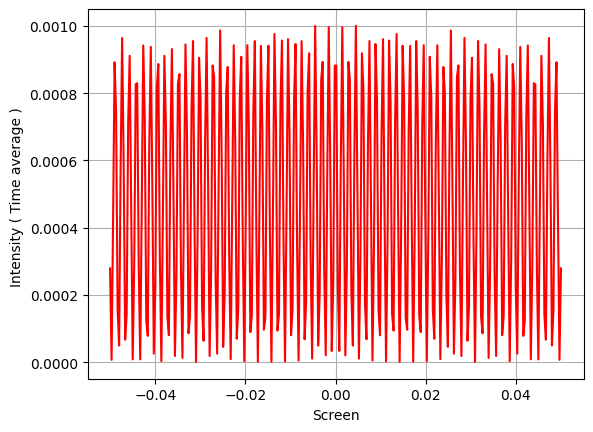

In [30]:
plt.plot(y,I0/len(t1),color="red")
plt.xlabel("Screen")
plt.ylabel("Intensity ( Time average ) ")
plt.grid(True)

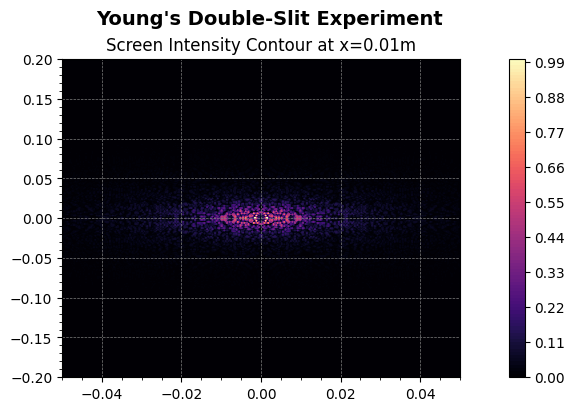

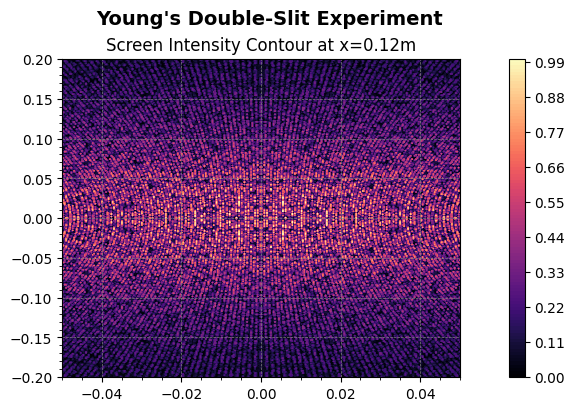

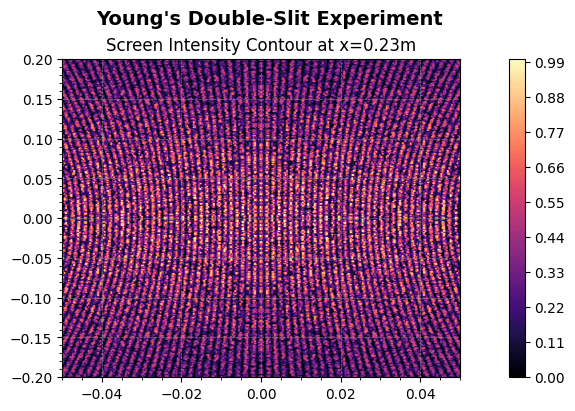

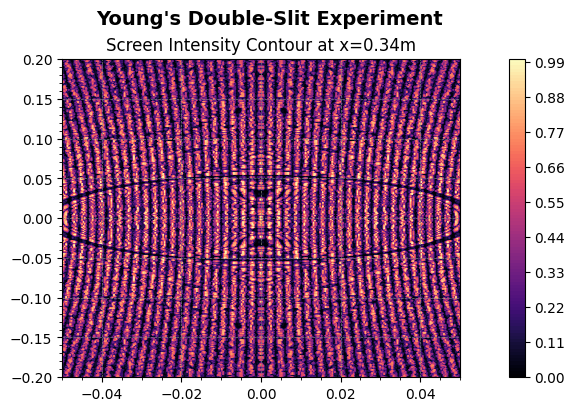

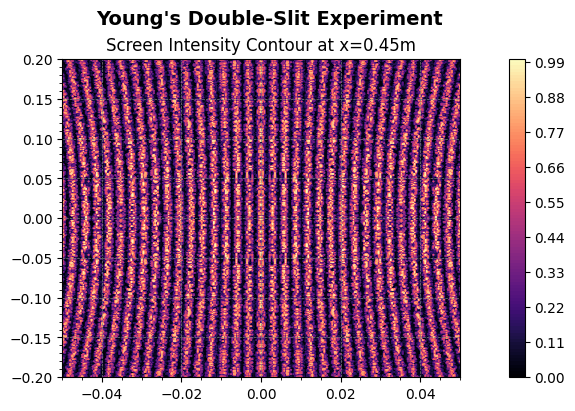

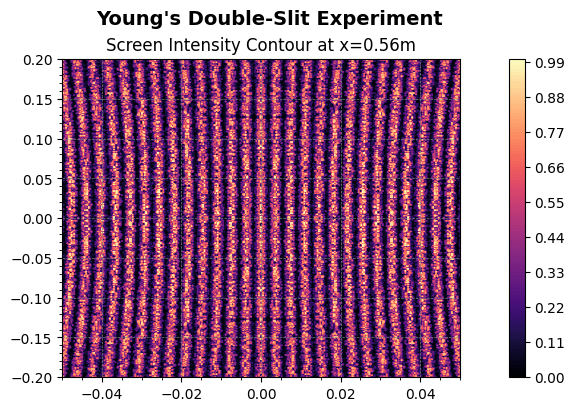

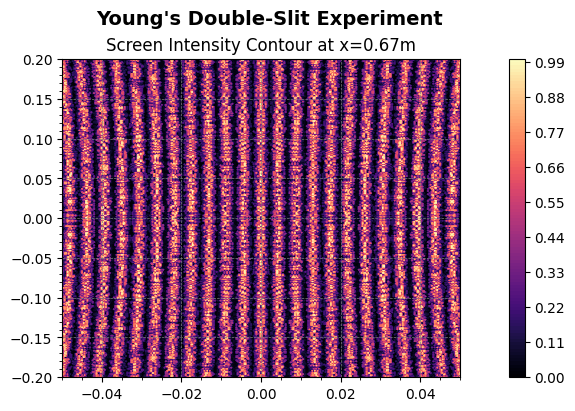

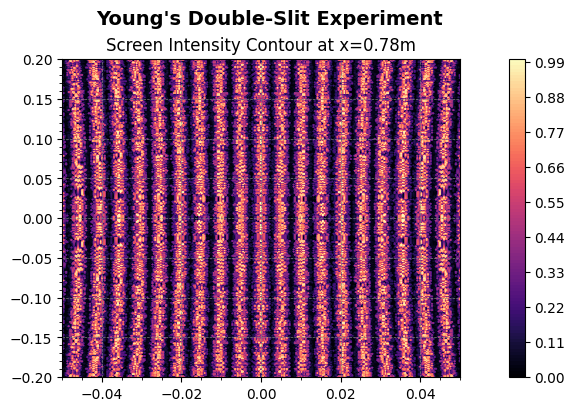

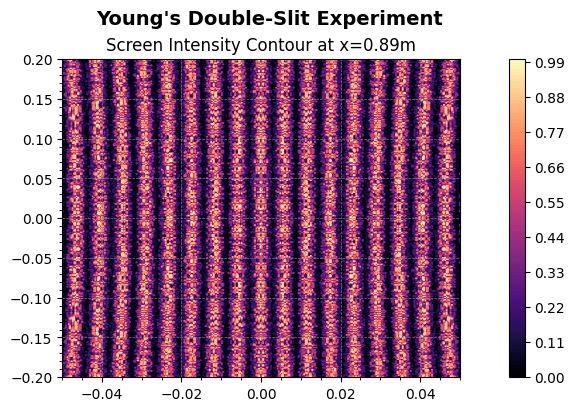

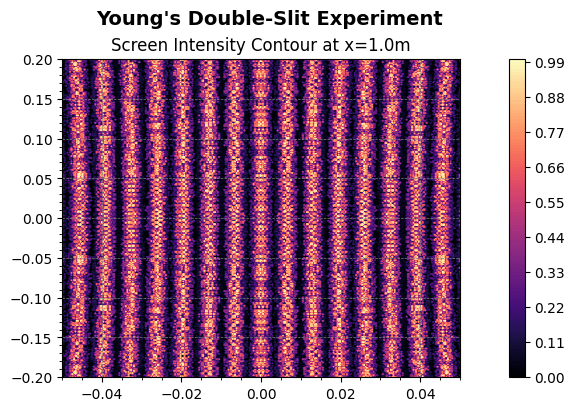

In [ ]:
D=np.linspace(0.01,1,10)

for n in D:
    plot(n,t)